In [1]:
import awkward as ak
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import os

data_dir = r"C:\Users\phili\Desktop\Studium\8. Semester\Semesterarbeit\data"

datasets = {
    "minbias":       "minbias_kinematics.parquet",
    "QCD_HT50toInf": "QCD_HT50toInf_kinematics.parquet",
    "ggHbb":         "ggHbb_kinematics.parquet",
    "VBFHbb":        "VBFHbb_kinematics.parquet",
}

data = {}
for name, fname in datasets.items():
    table = pq.read_table(os.path.join(data_dir, fname))
    data[name] = {
        "pt":  ak.from_arrow(table["L1T_JetPuppiAK8_PT"]),
        "eta": ak.from_arrow(table["L1T_JetPuppiAK8_Eta"]),
        "phi": ak.from_arrow(table["L1T_JetPuppiAK8_Phi"]),
    }
print("Loaded all datasets.")

Loaded all datasets.


## Basic Statistics

In [9]:
for name, d in data.items():
    pt = d["pt"]
    n_events = len(pt)
    n_jets = ak.sum(ak.num(pt))
    n_events_with_jet = ak.sum(ak.num(pt) > 0)
    avg_jets = ak.mean(ak.num(pt))
    flat_pt = ak.to_numpy(ak.flatten(pt))
    print(f"--- {name} ---")
    print(f"  Events:                {n_events:>10,}")
    print(f"  Events with >=1 jet:   {n_events_with_jet:>10,}  ({100*n_events_with_jet/n_events:.1f}%)")
    print(f"  Total jets:            {n_jets:>10,}")
    print(f"  Avg jets/event:        {float(avg_jets):>10.3f}")
    print(f"  PT  — mean: {flat_pt.mean():.1f}, median: {np.median(flat_pt):.1f}, max: {flat_pt.max():.1f} GeV")
    print()

--- minbias ---
  Events:                105,000,000
  Events with >=1 jet:        1,264  (0.0%)
  Total jets:                 1,344
  Avg jets/event:             0.000
  PT  — mean: 228.9, median: 218.1, max: 1078.0 GeV

--- QCD_HT50toInf ---
  Events:                101,181,400
  Events with >=1 jet:    3,019,612  (3.0%)
  Total jets:             4,422,603
  Avg jets/event:             0.044
  PT  — mean: 318.0, median: 271.8, max: 3060.0 GeV

--- ggHbb ---
  Events:                10,493,169
  Events with >=1 jet:      686,871  (6.5%)
  Total jets:             1,017,149
  Avg jets/event:             0.097
  PT  — mean: 324.0, median: 275.2, max: 2788.0 GeV

--- VBFHbb ---
  Events:                10,391,302
  Events with >=1 jet:    1,077,601  (10.4%)
  Total jets:             1,569,710
  Avg jets/event:             0.151
  PT  — mean: 325.0, median: 269.8, max: 3256.0 GeV



## Jet Multiplicity per Event

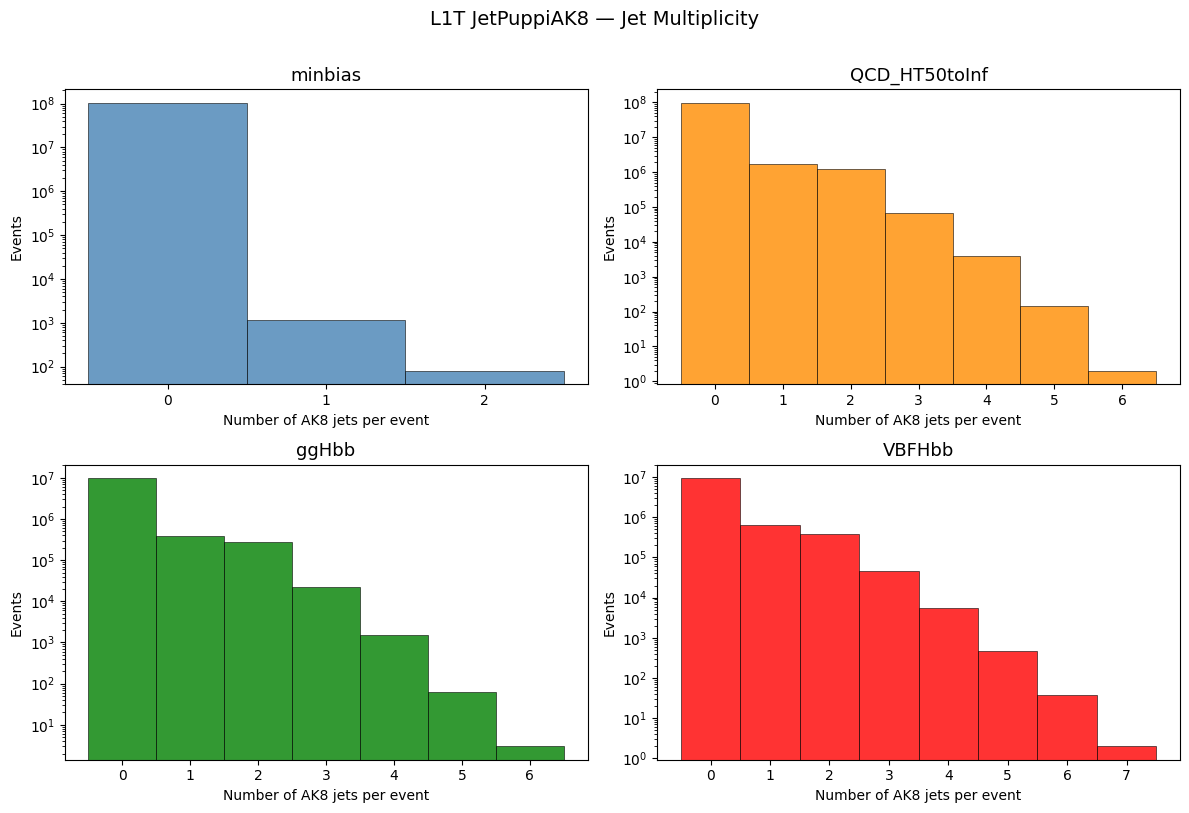

In [10]:
colors = {"minbias": "steelblue", "QCD_HT50toInf": "darkorange", "ggHbb": "green", "VBFHbb": "red"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, d) in zip(axes, data.items()):
    counts = ak.to_numpy(ak.num(d["pt"]))
    bins = np.arange(-0.5, counts.max() + 1.5, 1)
    ax.hist(counts, bins=bins, color=colors[name], alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Number of AK8 jets per event")
    ax.set_ylabel("Events")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.suptitle("L1T JetPuppiAK8 — Jet Multiplicity", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## PT Distribution

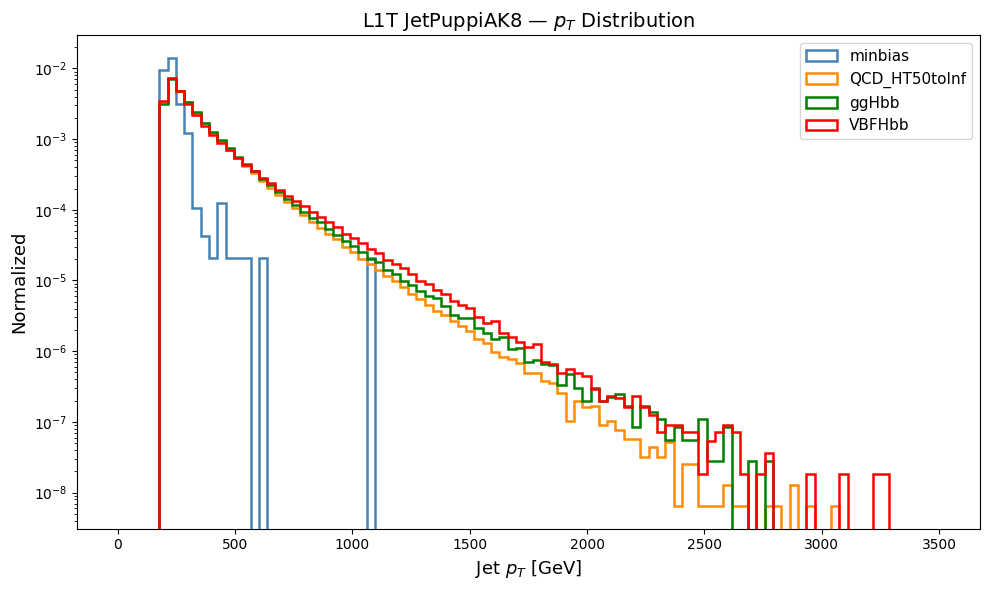

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, 3.5e3, 100)

for name, d in data.items():
    flat = ak.to_numpy(ak.flatten(d["pt"])).astype(float)
    ax.hist(flat, bins=bins, histtype="step", linewidth=1.8, label=name, color=colors[name], density=True)

ax.set_xlabel("Jet $p_T$ [GeV]", fontsize=13)
ax.set_ylabel("Normalized", fontsize=13)
ax.set_title("L1T JetPuppiAK8 — $p_T$ Distribution", fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Eta Distribution

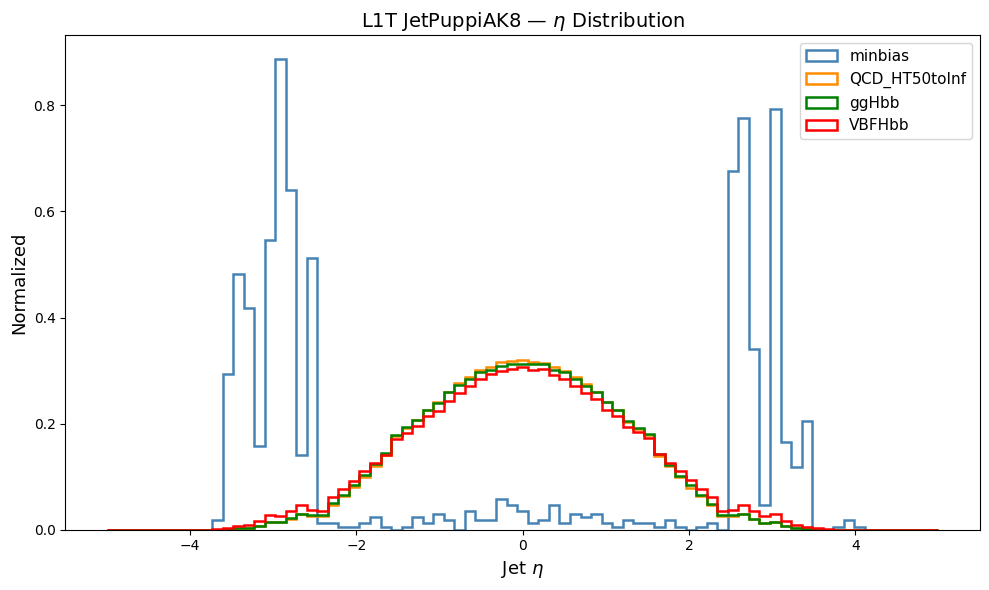

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(-5, 5, 80)

for name, d in data.items():
    flat = ak.to_numpy(ak.flatten(d["eta"])).astype(float)
    ax.hist(flat, bins=bins, histtype="step", linewidth=1.8, label=name, color=colors[name], density=True)

ax.set_xlabel("Jet $\eta$", fontsize=13)
ax.set_ylabel("Normalized", fontsize=13)
ax.set_title("L1T JetPuppiAK8 — $\eta$ Distribution", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Phi Distribution

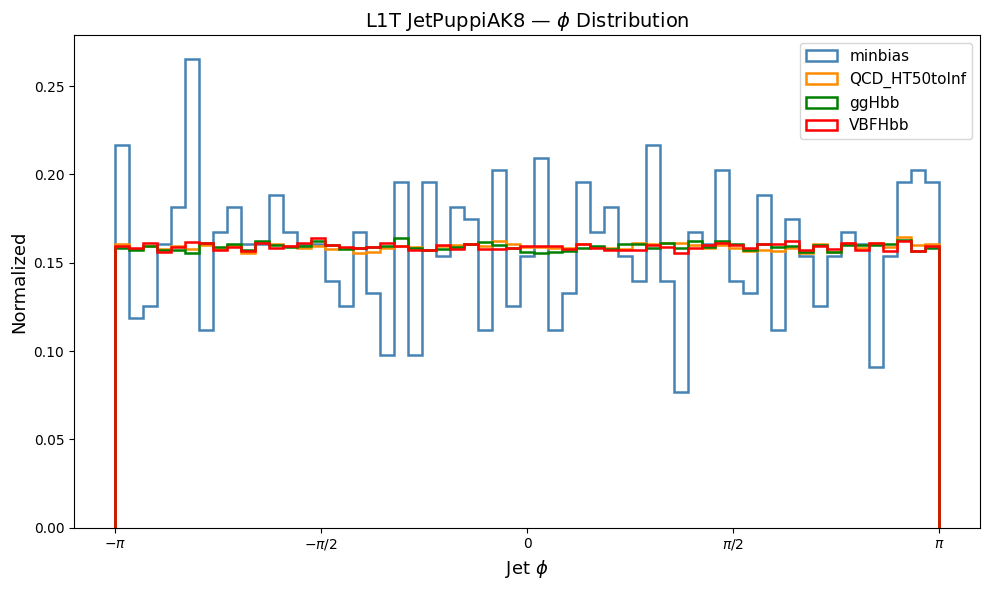

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(-np.pi, np.pi, 60)

for name, d in data.items():
    flat = ak.to_numpy(ak.flatten(d["phi"])).astype(float)
    ax.hist(flat, bins=bins, histtype="step", linewidth=1.8, label=name, color=colors[name], density=True)

ax.set_xlabel("Jet $\phi$", fontsize=13)
ax.set_ylabel("Normalized", fontsize=13)
ax.set_title("L1T JetPuppiAK8 — $\phi$ Distribution", fontsize=14)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## PT vs Eta (leading jet only)

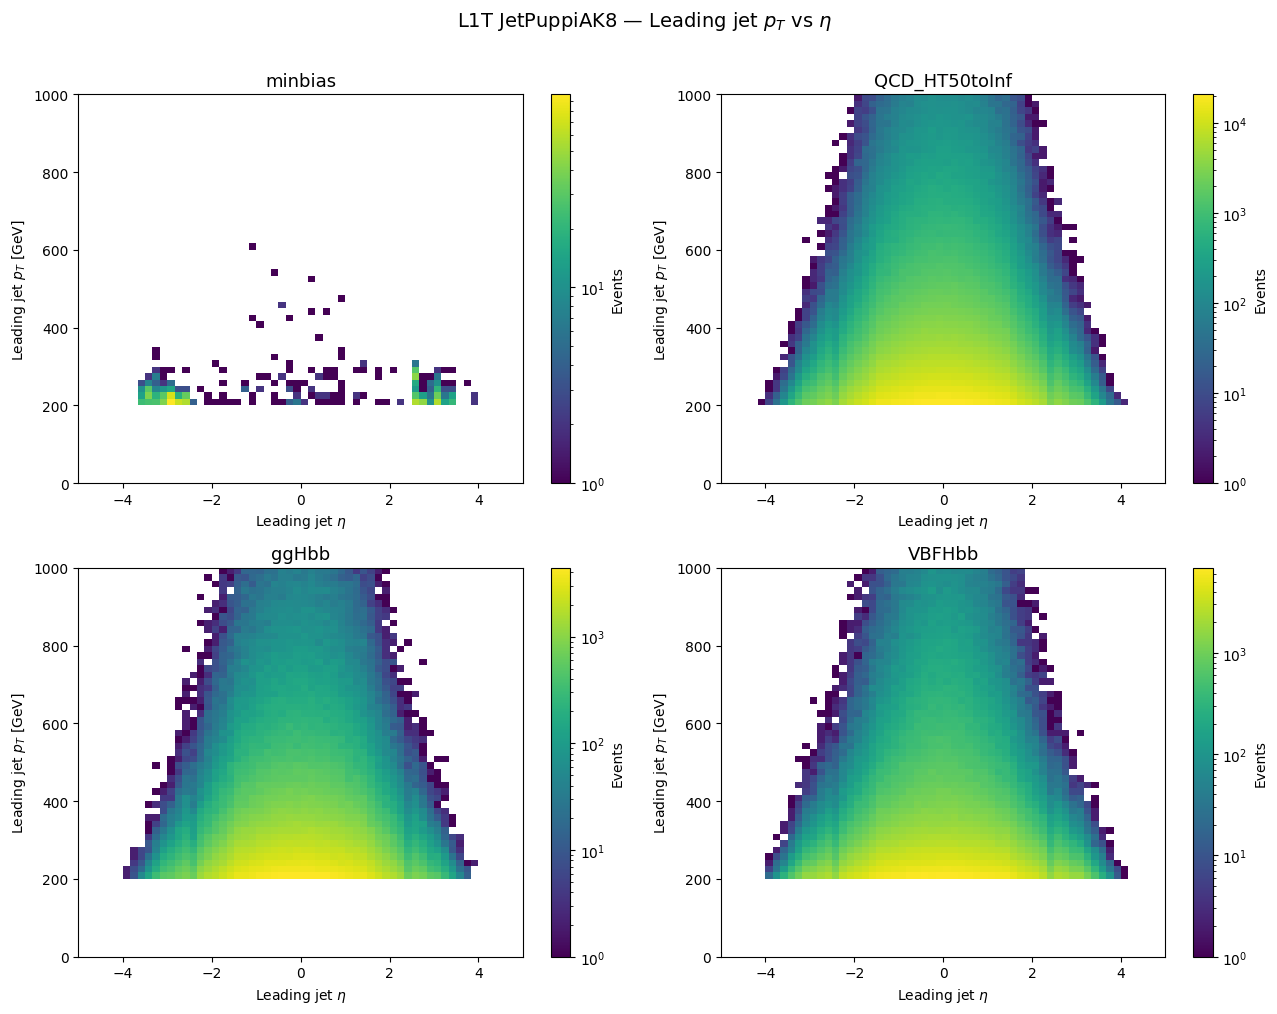

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (name, d) in zip(axes, data.items()):
    # leading jet only (first jet per event, where event has >=1 jet)
    mask = ak.num(d["pt"]) > 0
    pt_lead  = ak.to_numpy(d["pt"][mask][:, 0]).astype(float)
    eta_lead = ak.to_numpy(d["eta"][mask][:, 0]).astype(float)
    h = ax.hist2d(eta_lead, pt_lead, bins=[60, 60], range=[[-5, 5], [0, 1000]],
                  cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
    plt.colorbar(h[3], ax=ax, label="Events")
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Leading jet $\eta$")
    ax.set_ylabel("Leading jet $p_T$ [GeV]")

plt.suptitle("L1T JetPuppiAK8 — Leading jet $p_T$ vs $\eta$", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()